# Sensitivity Sweep Analysis

Analyzes the loss-weight + threshold sensitivity sweep for R2Q3 / R4Q3 in the TMI revision.

**Sweep:** 5 variants × 2 models × 10 seeds = 100 runs.

| Variant | sp_weight | threshold |
|---|---|---|
| default | 1.0 | 0.01 |
| sp_heavy | 5.0 | 0.01 |
| sp_light | 0.2 | 0.01 |
| tau_tight | 1.0 | 0.001 |
| tau_loose | 1.0 | 0.05 |

Metrics extracted from `train_logs.csv` at the epoch listed in `best_epoch.txt`:
- `val_forecast_loss` (MSE) — primary measure of how sensitive the forecasting objective is to the sweep.
- `val_sp_loss` — LeakyReLU(Hoyer − τ); reflects how much the sparsity penalty is active.
- `achieved_Hoyer ≈ val_sp_loss + τ` (valid when sp_loss > 0, which it is for all variants since the model converges to Hoyer ≈ 0.11 ≫ τ).


In [10]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
LOGS_ROOT = Path("/Users/ppopov1/DECIFRA/assets/logs")
DATASET = "ukb"
# MODELS = ["DECIFRA", "DECIFRA_MS"]
MODELS = ["DECIFRA_MS"]
# MODELS = ["DECIFRA"]
VARIANTS = ["default", "sp_heavy", "sp_light", "tau_tight", "tau_loose"]

# Plot order: defaults first, then sparsity sweep, then threshold sweep
VARIANT_ORDER = ["default", "sp_light", "sp_heavy", "tau_tight", "tau_loose"]

VARIANT_SPEC = {
    "default":   {"sp_weight": 1.0, "threshold": 0.01},
    "sp_heavy":  {"sp_weight": 5.0, "threshold": 0.01},
    "sp_light":  {"sp_weight": 0.2, "threshold": 0.01},
    "tau_tight": {"sp_weight": 1.0, "threshold": 0.001},
    "tau_loose": {"sp_weight": 1.0, "threshold": 0.05},
}

In [12]:
# Walk log dirs and collect best-epoch metrics per run.
records = []
missing = []
for model in MODELS:
    for variant in VARIANTS:
        run_dir = LOGS_ROOT / f"1_pretrain-{DATASET}-{model}-sens_{variant}"
        if not run_dir.exists():
            missing.append(str(run_dir))
            continue
        for seed_dir in sorted(p for p in run_dir.iterdir() if p.is_dir() and p.name.isdigit()):
            csv_path = seed_dir / "train_logs.csv"
            best_path = seed_dir / "best_epoch.txt"
            if not csv_path.exists() or not best_path.exists():
                missing.append(str(seed_dir))
                continue
            df = pd.read_csv(csv_path)
            best_epoch = int(open(best_path).read().strip())
            # best_epoch is the actual epoch number; locate the row
            best_row = df.loc[df["epoch"] == best_epoch].iloc[0]
            spec = VARIANT_SPEC[variant]
            records.append({
                "model": model,
                "variant": variant,
                "seed": int(seed_dir.name),
                "best_epoch": best_epoch,
                "sp_weight": spec["sp_weight"],
                "threshold": spec["threshold"],
                "val_forecast_loss": float(best_row["val_forecast_loss"]),
                "val_sp_loss": float(best_row["val_sp_loss"]),
                "val_loss": float(best_row["val_loss"]),
            })

raw = pd.DataFrame(records)
raw["achieved_hoyer"] = raw["val_sp_loss"] + raw["threshold"]

print(f"Loaded {len(raw)} runs from {raw['variant'].nunique()} variants x {raw['model'].nunique()} models")
if missing:
    print(f"\nMissing or incomplete ({len(missing)}):")
    for m in missing:
        print("  ", m)

raw.head()

Loaded 50 runs from 5 variants x 1 models


,model,variant,seed,best_epoch,sp_weight,threshold,val_forecast_loss,val_sp_loss,val_loss,achieved_hoyer
0,DECIFRA_MS,default,0,498,1.0,0.01,0.413387,0.111706,0.525093,0.121706
1,DECIFRA_MS,default,1,493,1.0,0.01,0.413044,0.111908,0.524953,0.121908
2,DECIFRA_MS,default,2,499,1.0,0.01,0.415073,0.111902,0.526975,0.121902
3,DECIFRA_MS,default,3,497,1.0,0.01,0.414090,0.111837,0.525927,0.121837
4,DECIFRA_MS,default,4,498,1.0,0.01,0.415786,0.112330,0.528116,0.122330


In [15]:
# Aggregate: mean +/- std across seeds, per (model, variant).
summary = (
    raw.groupby(["model", "variant"], observed=True)
    .agg(
        n=("seed", "count"),
        forecast_mean=("val_forecast_loss", "mean"),
        forecast_std=("val_forecast_loss", "std"),
        sp_loss_mean=("val_sp_loss", "mean"),
        sp_loss_std=("val_sp_loss", "std"),
        hoyer_mean=("achieved_hoyer", "mean"),
        hoyer_std=("achieved_hoyer", "std"),
    )
    .reset_index()
)
summary["variant"] = pd.Categorical(summary["variant"], categories=VARIANT_ORDER, ordered=True)
summary = summary.sort_values(["model", "variant"]).reset_index(drop=True)

# Pretty print
for col in ["forecast", "sp_loss", "hoyer"]:
    summary[f"{col}"] = summary.apply(
        lambda r: f"{r[f'{col}_mean']:.4f} \u00b1 {r[f'{col}_std']:.4f}", axis=1
    )

display_cols = ["model", "variant", "forecast", "sp_loss", "hoyer"]
summary[display_cols]

,model,variant,forecast,sp_loss,hoyer
0,DECIFRA_MS,default,0.4150 ± 0.0013,0.1119 ± 0.0002,0.1219 ± 0.0002
1,DECIFRA_MS,sp_light,0.4150 ± 0.0022,0.1151 ± 0.0008,0.1251 ± 0.0008
2,DECIFRA_MS,sp_heavy,0.4181 ± 0.0017,0.1109 ± 0.0000,0.1209 ± 0.0000
3,DECIFRA_MS,tau_tight,0.4157 ± 0.0013,0.1209 ± 0.0002,0.1219 ± 0.0002
4,DECIFRA_MS,tau_loose,0.4162 ± 0.0017,0.0718 ± 0.0003,0.1218 ± 0.0003


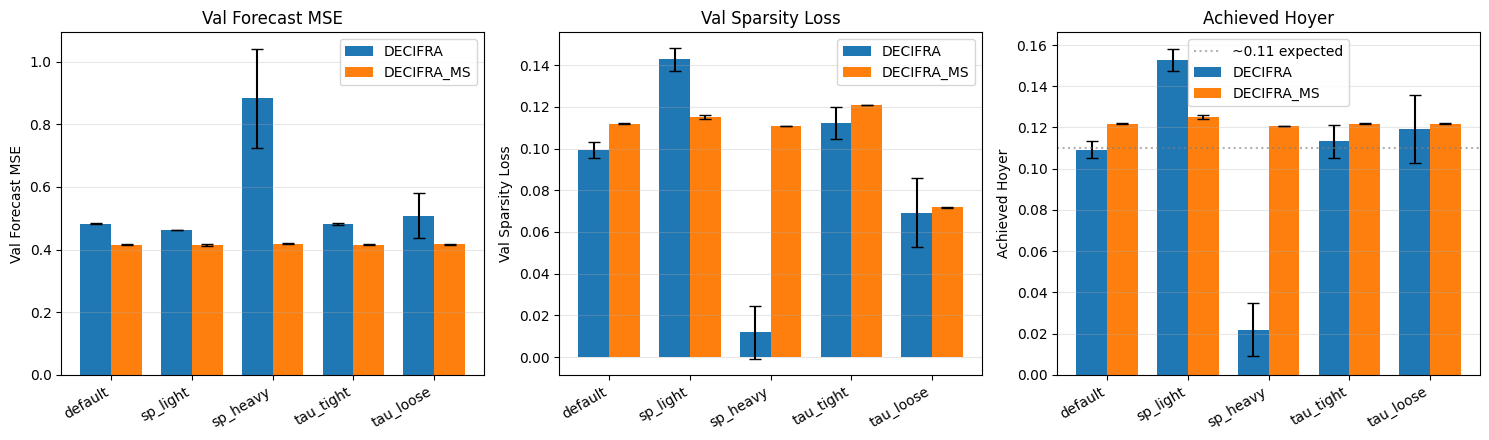

In [9]:
# Bar charts: forecast MSE, sparsity loss, achieved Hoyer.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics = [
    ("forecast", "Val Forecast MSE"),
    ("sp_loss", "Val Sparsity Loss"),
    ("hoyer", "Achieved Hoyer"),
]
x = np.arange(len(VARIANT_ORDER))
width = 0.38

for ax, (key, title) in zip(axes, metrics):
    for i, model in enumerate(MODELS):
        sub = summary[summary["model"] == model].set_index("variant").loc[VARIANT_ORDER]
        means = sub[f"{key}_mean"].astype(float).values
        stds = sub[f"{key}_std"].astype(float).values
        ax.bar(x + i * width, means, width, yerr=stds, capsize=4, label=model)
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(VARIANT_ORDER, rotation=30, ha="right")
    ax.set_title(title)
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")

# Reference line for achieved Hoyer: show the expected ~0.11 convergence value
axes[2].axhline(0.11, color="gray", linestyle=":", alpha=0.6, label="~0.11 expected")
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Training-curve overlays: val_forecast and val_sp_loss across epochs,
# averaged across the 10 seeds per (model, variant). Shows training dynamics,
# not just endpoint stability.
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
metrics = ["val_forecast_loss", "val_sp_loss"]

for row_idx, model in enumerate(MODELS):
    for col_idx, metric in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        for variant in VARIANT_ORDER:
            run_dir = LOGS_ROOT / f"1_pretrain-{DATASET}-{model}-sens_{variant}"
            if not run_dir.exists():
                continue
            per_seed = []
            for seed_dir in sorted(p for p in run_dir.iterdir() if p.is_dir() and p.name.isdigit()):
                csv_path = seed_dir / "train_logs.csv"
                if csv_path.exists():
                    df = pd.read_csv(csv_path)
                    per_seed.append(df[["epoch", metric]].rename(columns={metric: "value"}))
            if not per_seed:
                continue
            stacked = pd.concat(per_seed).groupby("epoch")["value"].agg(["mean", "std"])
            ax.plot(stacked.index, stacked["mean"], label=variant, linewidth=1.5)
            ax.fill_between(
                stacked.index,
                stacked["mean"] - stacked["std"],
                stacked["mean"] + stacked["std"],
                alpha=0.15,
            )
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric)
        ax.set_title(f"{model} — {metric}")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()